In [70]:
import warnings

warnings.filterwarnings("ignore")
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

from plotly import graph_objs as go
from plotly.offline import  init_notebook_mode, iplot

init_notebook_mode(connected=True)

In [71]:
def plotly_df(df, title=""):
    data = []

    for column in df.columns:
        trace = go.Scatter(x=df.index, y=df[column], mode="lines", name=column)
        data.append(trace)

    layout = dict(title=title)
    fig = dict(data=data, layout=layout)
    iplot(fig, show_link=False)

In [72]:
df = pd.read_csv(
    '../data/hour_online.csv',
    index_col=['Time'],
    parse_dates=['Time']
)
plotly_df(df, title='Online users')

# Скользящая средняя

In [73]:
def moving_average(series, n):
    return np.average(series[-n:])

moving_average(df.Users, 24)

np.float64(29858.333333333332)

In [74]:
def plot_Moving_Average(series, n, plot_bounds=False):
    if hasattr(series, 'squeeze'):
        series = series.squeeze()

    rolling_mean = series.rolling(window=n).mean()
    rolling_std = series.rolling(window=n).std()

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(series.index, series, label='Original', alpha=0.5)
    ax.plot(series.index, rolling_mean, label=f'Moving Average (n={n})', linewidth=2)

    if plot_bounds:
        lower_bound = (rolling_mean - 2 * rolling_std).squeeze()
        upper_bound = (rolling_mean + 2 * rolling_std).squeeze()

        ax.fill_between(
            series.index,
            lower_bound,
            upper_bound,
            alpha=0.2,
            label='±2 std dev'
        )

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%y-%m-%d"))

    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.title(f'Moving Average (window={n})')
    plt.tight_layout()
    plt.show()

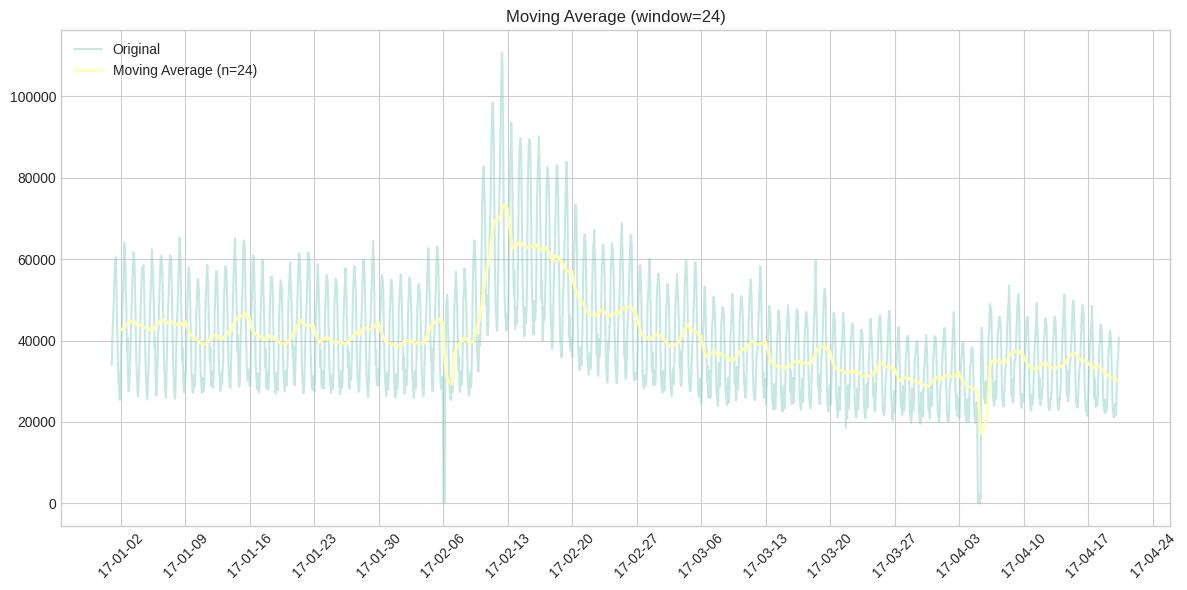

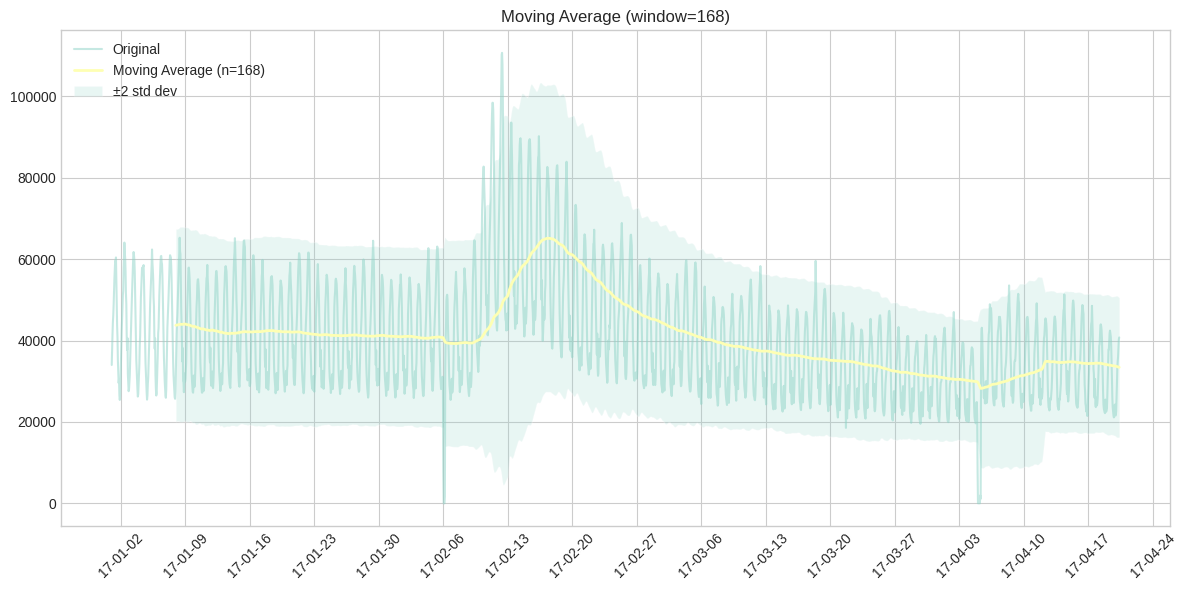

In [75]:
plot_Moving_Average(df, 24)
plot_Moving_Average(df, 24 * 7, plot_bounds=True)

# Скользящая взвешенная

In [76]:
def weighted_average(series, weights):
    result = 0.0
    for n in range(len(weights)):
        result += series.iloc[-n - 1] * weights[n]
    return float(result)

In [77]:
weighted_average(df.Users, weights=[0.6, 0.3, 0.01, 0.1, 0.5, 0.11])

61577.27999999999

# Экспоненциальное сглаживание

In [78]:
def exponential_smoothing(series, alpha):
    result = [series.iloc[0]]
    for n in range(1, len(series)):
        result.append(alpha * series.iloc[n] + (1 - alpha) * result[n - 1])
    return result

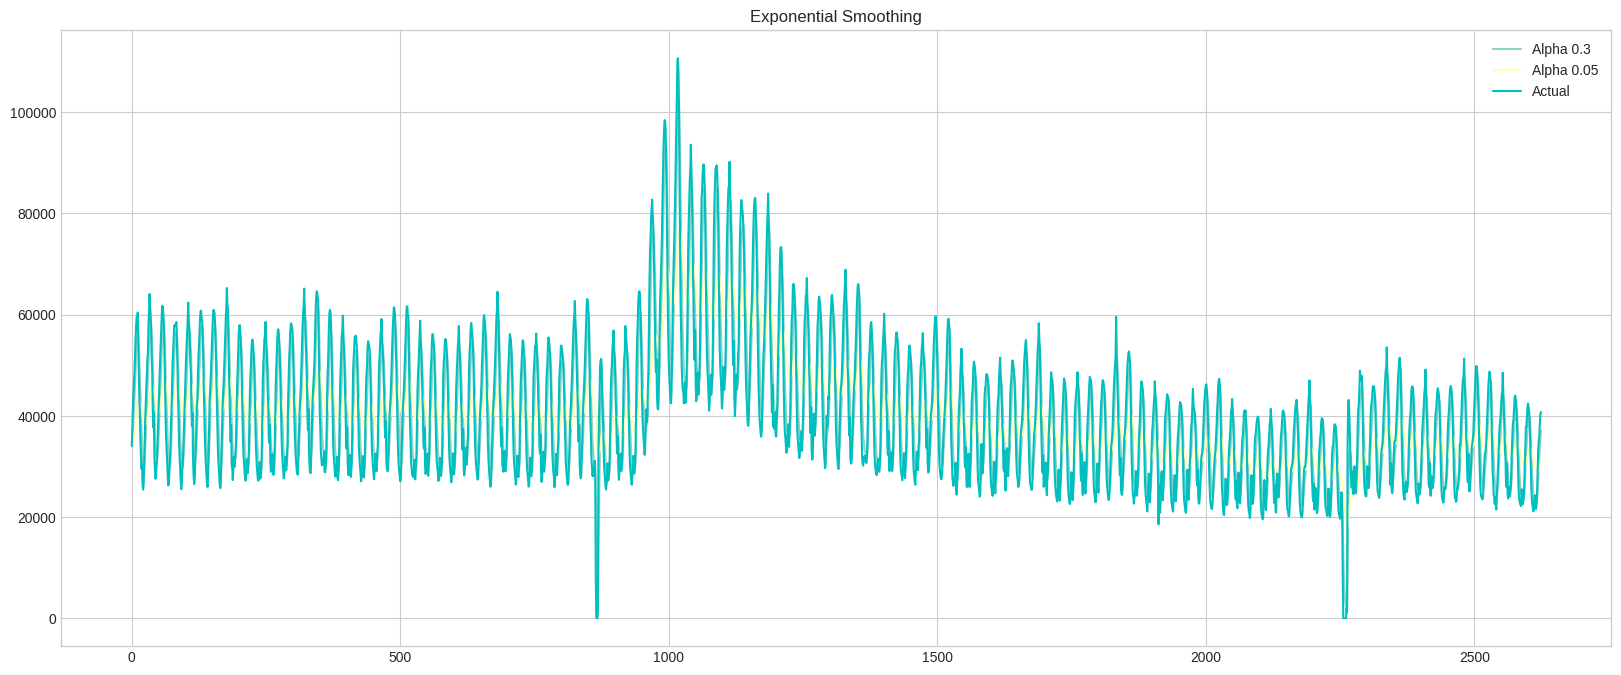

In [79]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(20, 8))
for alpha in [0.3, 0.05]:
    plt.plot(exponential_smoothing(df.Users, alpha), label="Alpha {}".format(alpha))
plt.plot(df.Users.values, 'c', label="Actual")
plt.legend(loc='best')
plt.axis('tight')
plt.title('Exponential Smoothing')
plt.grid(True)

# Двойное экспоненциальное сглаживание

In [80]:
def double_exponential_smoothing(series, alpha, beta):
    result = [series.iloc[0]]

    for n in range(1, len(series) + 1):
        if n == 1:
            level = series.iloc[0]
            trend = series.iloc[1] - series.iloc[0]
        if n >= len(series):
            value = result[-1]
        else:
            last_level, last_trend = level, trend
            level = alpha * series.iloc[n] + (1 - alpha) * (last_level + last_trend)
            trend = beta * (level - last_level) + (1 - beta) * last_trend
            value = level + trend
        result.append(value)

    return result

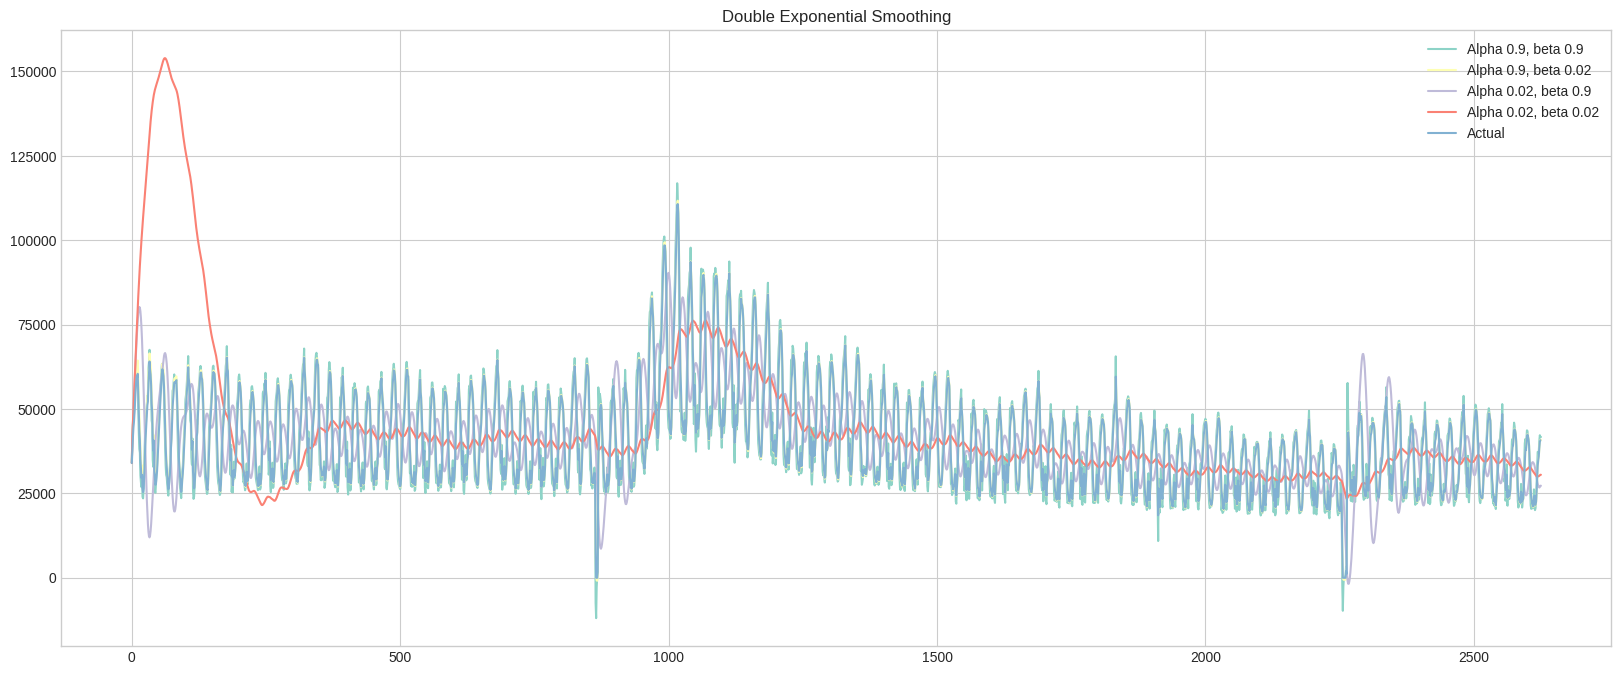

In [81]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(20, 8))
for alpha in [0.9, 0.02]:
    for beta in [0.9, 0.02]:
        plt.plot(
            double_exponential_smoothing(df.Users, alpha, beta),
            label="Alpha {}, beta {}".format(alpha, beta),
        )
plt.plot(df.Users.values, label="Actual")
plt.legend(loc="best")
plt.axis("tight")
plt.title("Double Exponential Smoothing")
plt.grid(True)